# XGBoost MI Pricing — Explainable Machine Learning for Mortgage Insurance
### Exploratory Data Analysis

This is the first notebook of the project **"XGBoost MI Pricing — Explainable Machine Learning for Mortgage Insurance"**

This notebook attempts to do perform exploratory data analysis on a pool of mortgage loans which have a mortgage insurance cover. We look at the distirbutions for certain numerical features like Original Loan Balances and Mortgage Insurance Premium Rate. We also check how premium varies by different categorical variables like Occupancy Type and Loan Purpose. 

The notebook also plots a heatmap to show how the weighted average mortgage insurance premium varies by different FICO/LTV buckets. Finally, we take a look at the correlation matrix between different variables. This analysis helps us identify the non-linear interactions between variables that can not be captures by GLMs and hence a ML algorithm like XGBoost would be needed. 

In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import import_ipynb
import importlib
from IPython.display import display
import seaborn as sns

In [2]:
#Load Loan Level Data
loan_level_data = pd.read_excel("00_LoanData.xlsx")

In [3]:
#See first few rows of the data to look at features included in the dataset
loan_level_data.head(5)

,Loan ID,Loan Purpose,Occupancy Type,Property State,Original FICO Score,Original LTV (%),Original Loan Balance ($),Age of Loan (Months),Original Interest Rate (%),Current Loan Balance ($),Original DTI (%),Multiple Borrowers,Delinquency Status,MI Premium Rate (bps)
0,LN00000001,Purchase,Second Home,FL,737,80.97,479000,17,6.688,471578.07,27.6,No,Current,31.5
1,LN00000002,Refinance,Second Home,PA,716,90.45,256000,9,7.490,254243.27,29.2,Yes,Current,25.1
2,LN00000003,Refinance,Primary Residence,GA,792,95.15,340000,4,6.364,338727.61,37.4,No,Current,43.4
3,LN00000004,Purchase,Primary Residence,TX,773,86.79,334000,8,6.672,331618.12,38.6,Yes,Current,14.0
4,LN00000005,Purchase,Primary Residence,KY,746,93.06,305000,14,7.408,301639.44,33.3,Yes,Current,29.0


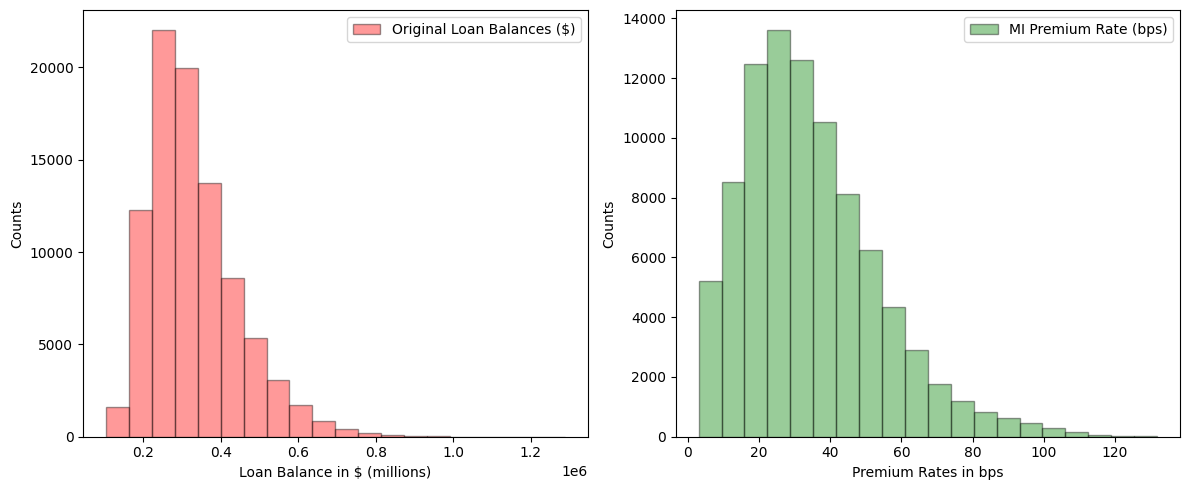

In [4]:
#Distirbution of Loan Balances and Premium Rates 
fig, ax =  plt.subplots(1, 2, figsize=(12,5))

#Distribution of Loan Balances
ax[0].hist(loan_level_data['Original Loan Balance ($)'], bins=20,color='r', alpha=0.4, label='Original Loan Balances ($)', edgecolor='black')
ax[0].legend()
ax[0].set_xlabel('Loan Balance in $ (millions)')
ax[0].set_ylabel('Counts')
#Distribution of Premium Rates
ax[1].hist(loan_level_data['MI Premium Rate (bps)'], bins=20,color='g', alpha=0.4, label='MI Premium Rate (bps)', edgecolor='black')
ax[1].legend()
ax[1].set_xlabel('Premium Rates in bps')
ax[1].set_ylabel('Counts')

plt.tight_layout()
plt.show()


Loan Balances seem positively skewed which makes sense. 
Premium Rates also seem positively skewed - premium rates mostly lie between 10-40 bps. 
Our loan pool has a major proporiton of prime loans which is why we see a skewed distribution here for premium rates. 

In [4]:
#Exploring categorical variables to check what unique items each feature contains
print(f"Unique values in 'Occupancy Type': {list(loan_level_data['Occupancy Type'].unique())}")
print(f"Unique values in 'Loan Purpose': {list(loan_level_data['Loan Purpose'].unique())}")

#Counting the number of states in data
print(f"The number of U.S. States in loan data are: {len(list(loan_level_data['Property State'].unique()))}")

Unique values in 'Occupancy Type': ['Second Home', 'Primary Residence', 'Investment Property']
Unique values in 'Loan Purpose': ['Purchase', 'Refinance']
The number of U.S. States in loan data are: 50


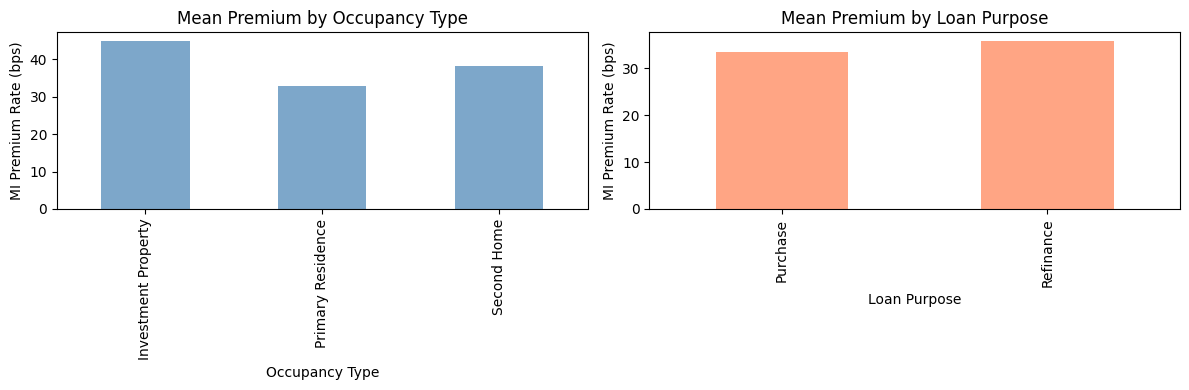

In [6]:
#Mean premium by occupancy and loan purpose
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
loan_level_data.groupby('Occupancy Type')['MI Premium Rate (bps)'].mean().plot(kind='bar', ax=ax[0], color='steelblue', alpha=0.7)
ax[0].set_title('Mean Premium by Occupancy Type')
ax[0].set_ylabel('MI Premium Rate (bps)')

loan_level_data.groupby('Loan Purpose')['MI Premium Rate (bps)'].mean().plot(kind='bar', ax=ax[1], color='coral', alpha=0.7)
ax[1].set_title('Mean Premium by Loan Purpose')
ax[1].set_ylabel('MI Premium Rate (bps)')
plt.tight_layout()
plt.show()

Investment properties carry the highest mean premium at ~45 bps, reflecting the greater default risk associated with non-owner-occupied properties. Refinance loans show marginally higher premiums than purchase loans, consistent with the higher risk profile of cash-out refinancing at elevated LTVs.

In [7]:
#Weighted Average Premium Rates and Number of Loans by LTV/FICO buckets
fico_ltv_bucket = pd.DataFrame((np.zeros((5,5))))
number_of_loans = pd.DataFrame((np.zeros((5,5))))

#FICO LTV buckets
fico_buckets = ['600-650','650-700','700-750','750-800','800-850']
ltv_buckets = ['75-80','80-85','85-90','90-95','95-100']

#Give column headers and row index
fico_ltv_bucket.columns = fico_buckets
fico_ltv_bucket.index = ltv_buckets
number_of_loans.columns = fico_buckets
number_of_loans.index = ltv_buckets

#Function to find WA premium
def wa_premium(fico_band, ltv_band):
    start_point_fico = int(fico_band[:3])
    end_point_fico = int(fico_band[4:])
    start_point_ltv = int(ltv_band[:2])
    end_point_ltv = int(ltv_band[3:])
    filtered_df = loan_level_data[(loan_level_data['Original FICO Score']>start_point_fico)&(loan_level_data['Original FICO Score']<=end_point_fico)&(loan_level_data['Original LTV (%)']>start_point_ltv)&(loan_level_data['Original LTV (%)']<=end_point_ltv)]
    return round((filtered_df['Original Loan Balance ($)']*filtered_df['MI Premium Rate (bps)']).sum()/(filtered_df['Original Loan Balance ($)'].sum()),2)

#Function to find count of loans
def count_of_loans(fico_band, ltv_band):
    start_point_fico = int(fico_band[:3])
    end_point_fico = int(fico_band[4:])
    start_point_ltv = int(ltv_band[:2])
    end_point_ltv = int(ltv_band[3:])
    filtered_df = loan_level_data[(loan_level_data['Original FICO Score']>start_point_fico)&(loan_level_data['Original FICO Score']<=end_point_fico)&(loan_level_data['Original LTV (%)']>start_point_ltv)&(loan_level_data['Original LTV (%)']<=end_point_ltv)]
    return filtered_df.shape[0]

#Fill the FICO_LTV Matrix
fico_ltv_bucket = fico_ltv_bucket.apply(
    lambda col: col.index.map(lambda ltv_band: wa_premium(col.name, ltv_band))
)

#Fill the Count Matrix
number_of_loans = number_of_loans.apply(lambda col: col.index.map(lambda ltv_band: count_of_loans(col.name,ltv_band)))

print("Weighted Average MI Premium Rate (bps) by FICO and LTV Band")
display(fico_ltv_bucket.style.format("{:.1f}").background_gradient(cmap='RdYlGn_r'))

print("Number of Loans by FICO and LTV Band")
display(number_of_loans.style.format("{:.0f}").background_gradient(cmap='Blues'))

Weighted Average MI Premium Rate (bps) by FICO and LTV Band


,600-650,650-700,700-750,750-800,800-850
75-80,46.9,30.7,17.7,12.3,9.5
80-85,50.4,35.1,21.4,15.6,13.9
85-90,55.2,39.6,26.3,20.4,18.3
90-95,78.6,61.2,39.9,33.8,31.6
95-100,102.3,81.3,57.4,50.8,50.2


Number of Loans by FICO and LTV Band


,600-650,650-700,700-750,750-800,800-850
75-80,488,1352,3135,2131,160
80-85,1247,3539,7517,5202,449
85-90,1812,5222,11575,7806,598
90-95,2114,6074,13486,9057,759
95-100,454,1200,2664,1804,155


The matrix shows appropriate relation between FICO-LTV and premium rates. 
Buckets where data is low may have higher degree of uncertainty in rate estimates and our XGBoost modelling may have higher or lower predictions than actuals in those areas. 
The heatmap also shows why a linear model may fail because the interaction effect between FICO and LTV may not be additive. 

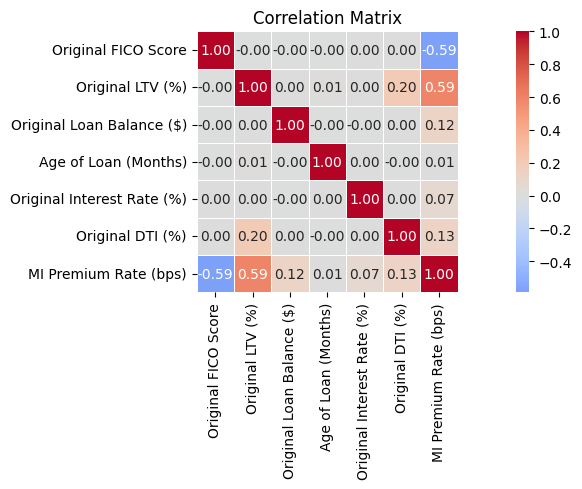

In [8]:
#Correlation Matrix between Premium Rates and Features
corr_cols = ['Original FICO Score', 'Original LTV (%)', 'Original Loan Balance ($)',
             'Age of Loan (Months)', 'Original Interest Rate (%)',
             'Original DTI (%)', 'MI Premium Rate (bps)']

corr_matrix = loan_level_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

Pearson correlation captures only linear relationships. 
Several features show low correlation with MI Premium Rate here but may still carry predictive signal through non-linear effects, threshold behaviour, or interactions with other features. 
XGBoost is well suited to detect these patterns without requiring explicit feature engineering of interactions.

### End of Notebook